In [4]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

# Load dataset directly from local folder (make sure the CSV file is in the same directory)
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset dimensions:", df.shape)

Dataset loaded successfully!
Dataset dimensions: (7043, 21)


In [5]:
# Replace empty spaces with NaN to detect hidden missing values in object columns
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", float("nan"), regex=True)

# Check missing values count per column
print("--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
# Convert TotalCharges from string/object to numeric, forcing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Data type of TotalCharges now:", df["TotalCharges"].dtype)
print("Null count after conversion:", df["TotalCharges"].isnull().sum())

Data type of TotalCharges now: float64
Null count after conversion: 11


In [7]:
# Decision: Since tenure is 0 for these 11 new customers, TotalCharges is set to 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify if any missing values remain in TotalCharges
print(
    "Missing values in TotalCharges after filling:",
    df["TotalCharges"].isnull().sum(),
)

Missing values in TotalCharges after filling: 0


In [8]:
# Check if customerID has any duplicates
duplicates_count = df["customerID"].duplicated().sum()
print(f"Total duplicate customerIDs found: {duplicates_count}")

Total duplicate customerIDs found: 0


In [9]:
# Clean redundant categories for add-on and phone services
cols_to_clean = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "MultipleLines",
]

for col in cols_to_clean:
  df[col] = df[col].replace(
      {"No internet service": "No", "No phone service": "No"}
  )

print('Categories successfully cleaned and merged into "No".')

Categories successfully cleaned and merged into "No".


In [10]:
# Convert SeniorCitizen from 0/1 to 'No'/'Yes' for consistency
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print(df["SeniorCitizen"].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [11]:
# Create a binary encoded column for Churn (0 for No, 1 for Yes)
df["Churn_flag"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df[["Churn", "Churn_flag"]].head(10))

  Churn  Churn_flag
0    No           0
1    No           0
2   Yes           1
3    No           0
4   Yes           1
5   Yes           1
6    No           0
7    No           0
8   Yes           1
9    No           0


In [12]:
import os

# Create 'data/processed' directory if it does not exist
os.makedirs("data/processed", exist_ok=True)

# Save the final cleaned dataframe to CSV
output_path = "data/processed/clean_data.csv"
df.to_csv(output_path, index=False)

print(f"Cleaned dataset successfully saved to: {output_path}")
print("Final Cleaned Shape:", df.shape)

Cleaned dataset successfully saved to: data/processed/clean_data.csv
Final Cleaned Shape: (7043, 22)


In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style for plots
sns.set_theme(style='whitegrid')

# Create reports/figures directory if it doesn't exist
os.makedirs('reports/figures', exist_ok=True)

# Load the cleaned dataset
df = pd.read_csv('data/processed/clean_data.csv')
print('Cleaned dataset loaded successfully. Shape:', df.shape)

Cleaned dataset loaded successfully. Shape: (7043, 22)


--- Churn Count ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Churn Percentage ---
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


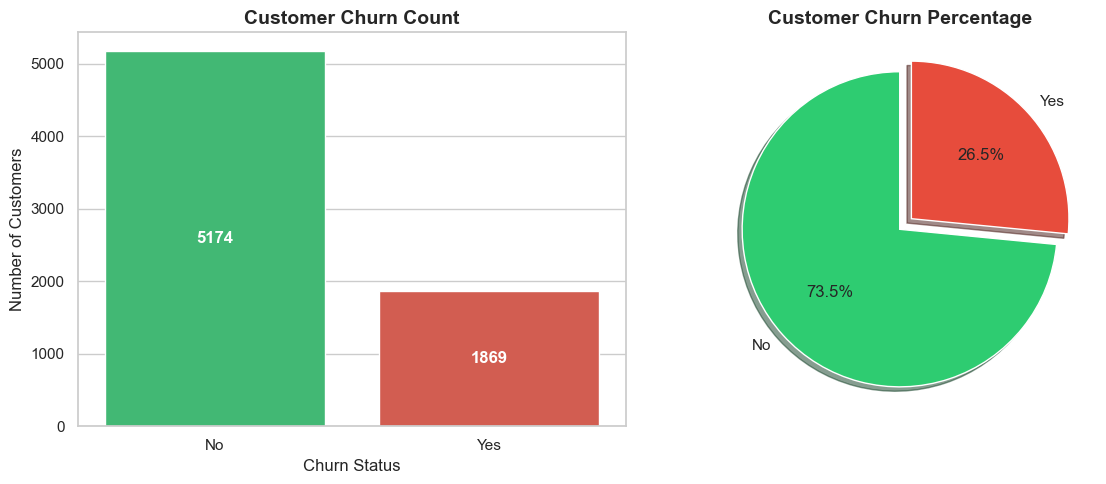


Figure saved successfully to reports/figures/churn_distribution.png


In [15]:
# Calculate churn counts and percentages
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print('--- Churn Count ---')
print(churn_counts)
print('\n--- Churn Percentage ---')
print(churn_percentages.round(2))

# Plotting Churn Distribution (Bar Chart & Pie Chart side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart (Added hue=x and legend=False to avoid Seaborn warning)
sns.countplot(
    data=df,
    x='Churn',
    hue='Churn',
    palette=['#2ecc71', '#e74c3c'],
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Status', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# Adding values on top of bars
for p in axes[0].patches:
  axes[0].annotate(
      f'{int(p.get_height())}',
      (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
      ha='center',
      va='center',
      fontsize=12,
      color='white',
      fontweight='bold',
  )

# Pie Chart
axes[1].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.1),
    shadow=True,
)
axes[1].set_title('Customer Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
# Save figure
plt.savefig('reports/figures/churn_distribution.png', dpi=300)
plt.show()
print(
    '\nFigure saved successfully to reports/figures/churn_distribution.png'
);

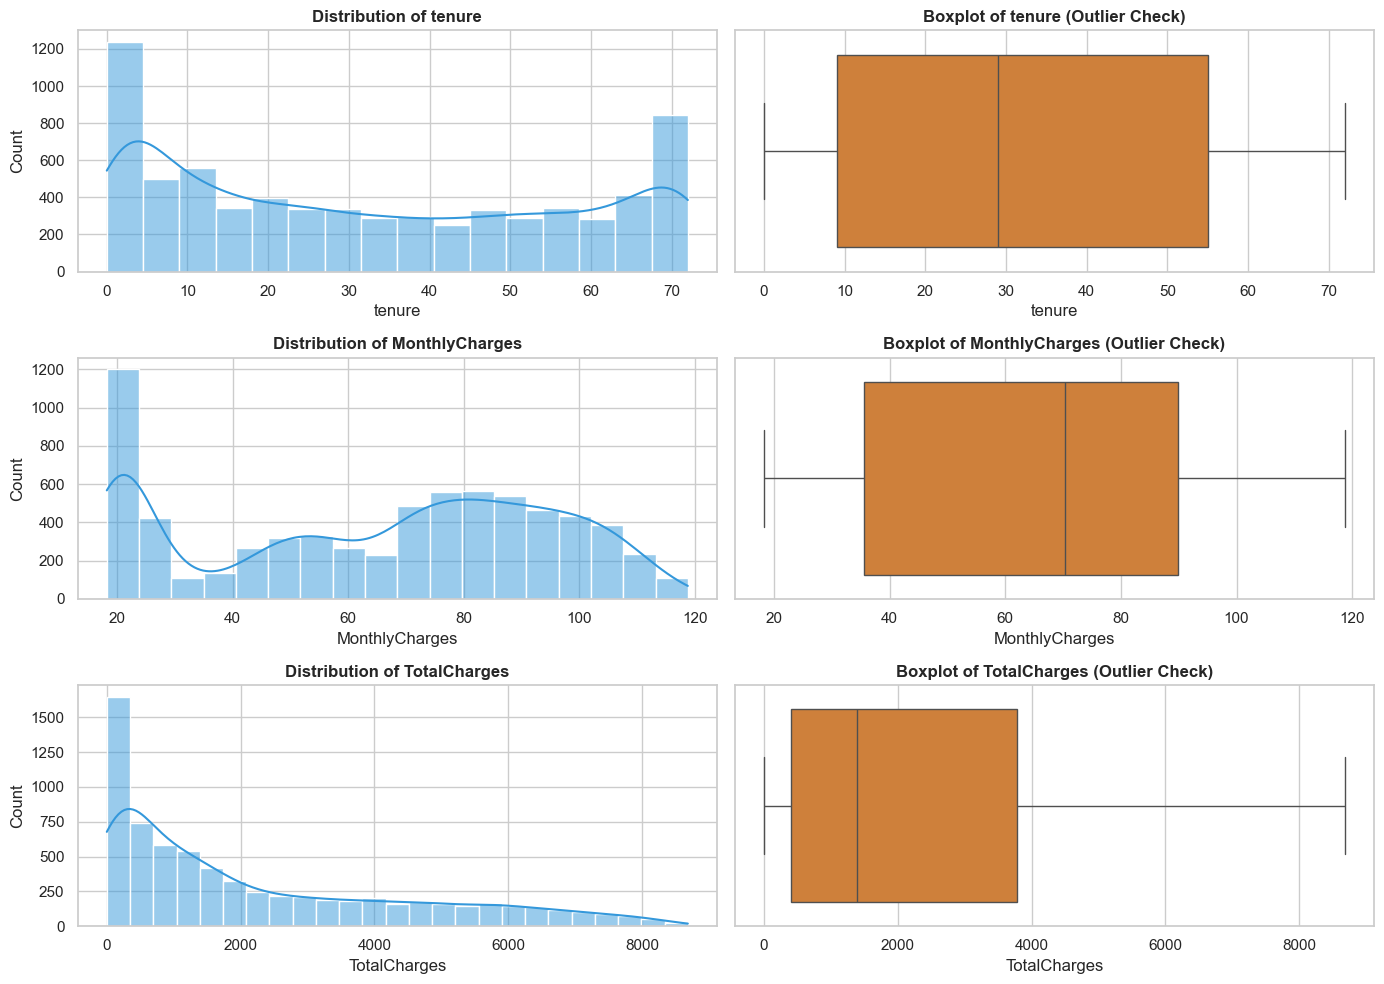


Numeric univariate analysis figure saved to reports/figures/numeric_univariate_analysis.png


In [16]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Plot histograms and boxplots for numeric features
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 10))

for i, col in enumerate(numeric_cols):
  # Histogram / KDE
  sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#3498db')
  axes[i, 0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
  axes[i, 0].set_xlabel(col)
  axes[i, 0].set_ylabel('Count')

  # Boxplot for Outliers
  sns.boxplot(x=df[col], ax=axes[i, 1], color='#e67e22')
  axes[i, 1].set_title(f'Boxplot of {col} (Outlier Check)', fontsize=12, fontweight='bold')
  axes[i, 1].set_xlabel(col)

plt.tight_layout()
# Save figure
plt.savefig('reports/figures/numeric_univariate_analysis.png', dpi=300)
plt.show()
print('\nNumeric univariate analysis figure saved to reports/figures/numeric_univariate_analysis.png')

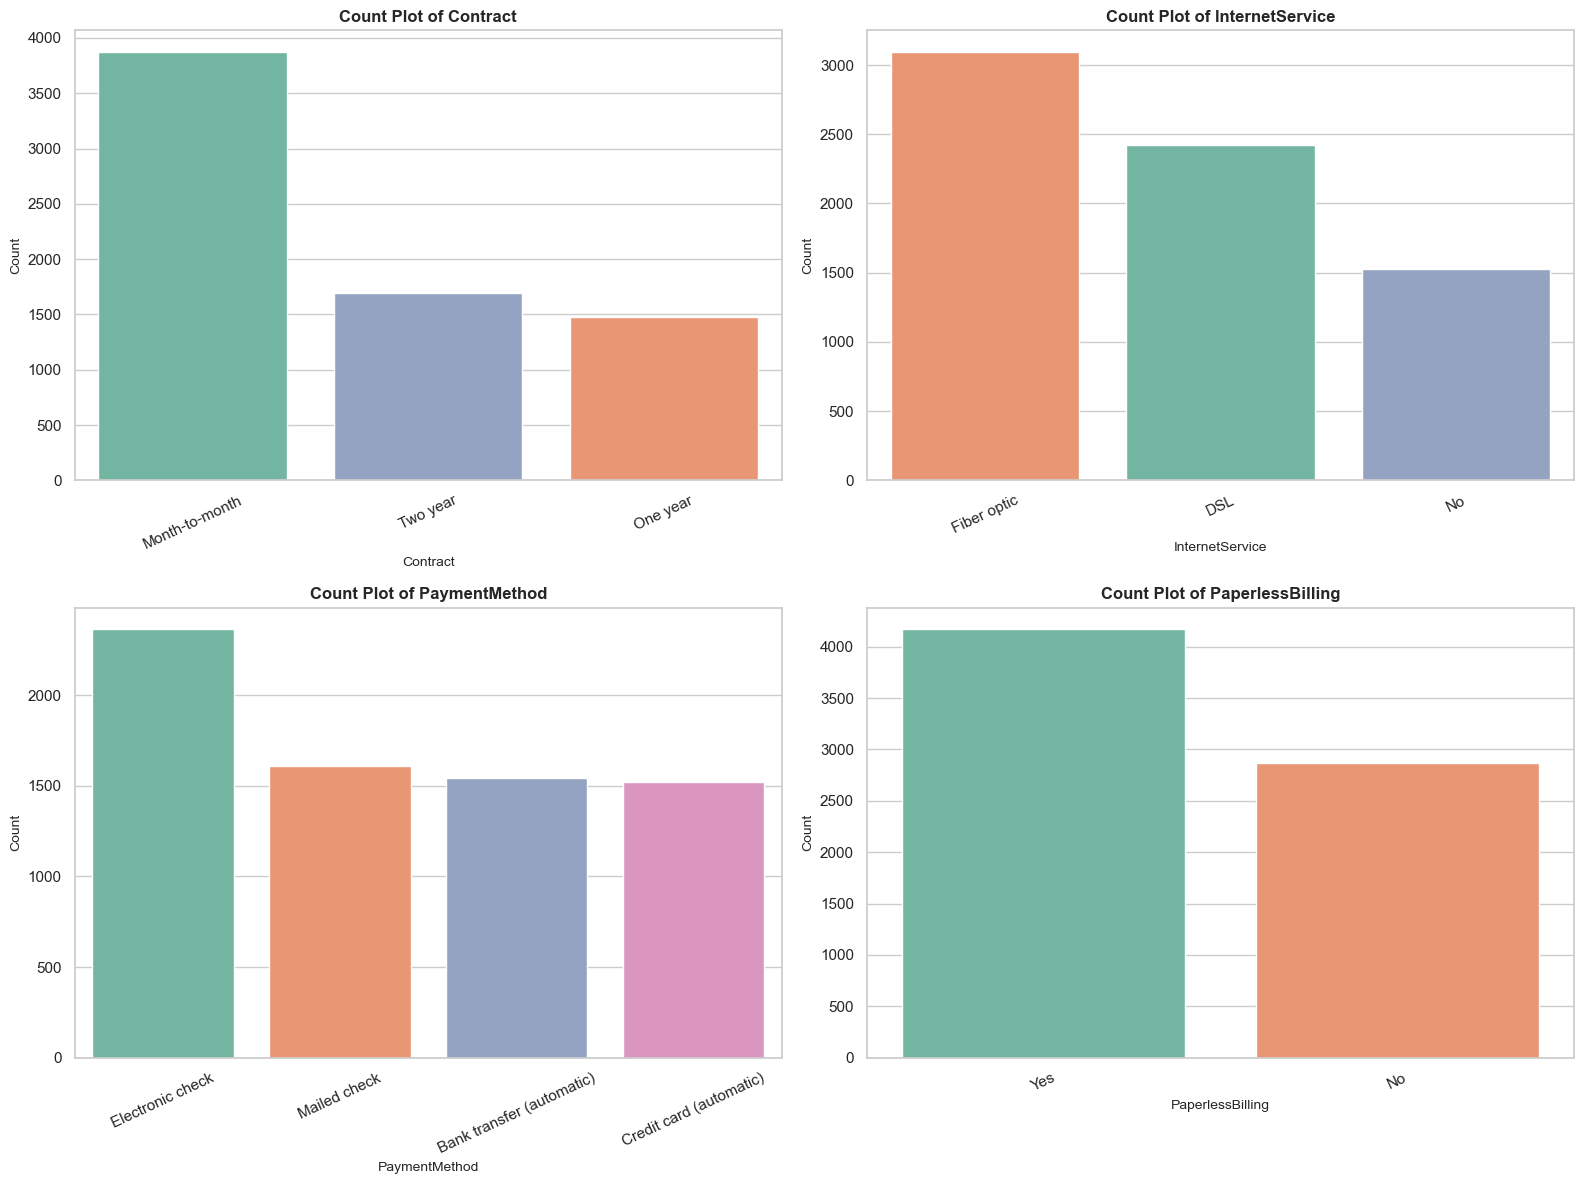


Categorical univariate analysis figure saved to reports/figures/categorical_univariate_analysis.png


In [17]:
cat_cols_to_plot = [
    'Contract',
    'InternetService',
    'PaymentMethod',
    'PaperlessBilling',
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
  sns.countplot(
      data=df,
      x=col,
      hue=col,
      order=df[col].value_counts().index,
      palette='Set2',
      legend=False,
      ax=axes[i],
  )
  axes[i].set_title(f'Count Plot of {col}', fontsize=12, fontweight='bold')
  axes[i].set_xlabel(col, fontsize=10)
  axes[i].set_ylabel('Count', fontsize=10)
  axes[i].tick_params(axis='x', rotation=25)

plt.tight_layout()
# Save figure
plt.savefig('reports/figures/categorical_univariate_analysis.png', dpi=300)
plt.show()
print(
    '\nCategorical univariate analysis figure saved to'
    ' reports/figures/categorical_univariate_analysis.png'
);

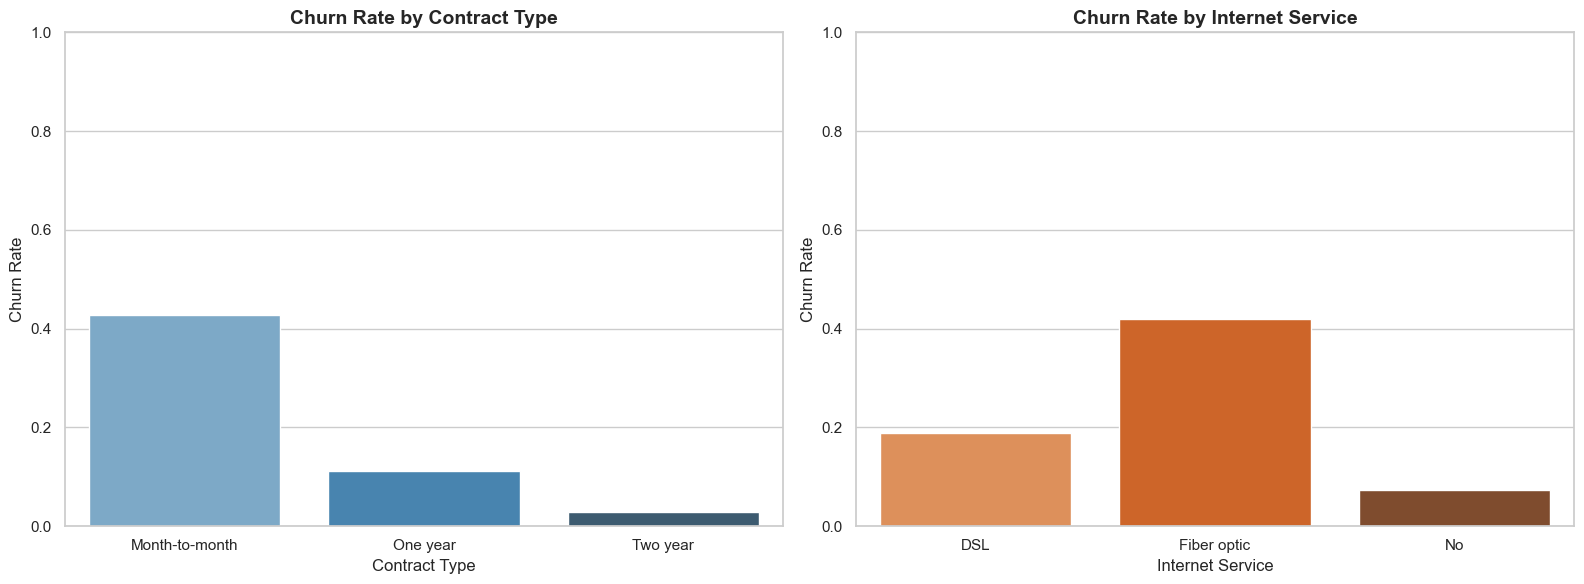

Saved: reports/figures/churn_by_contract_internet.png


In [25]:
#Bivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Churn Rate by Contract
sns.barplot(
    data=df,
    x='Contract',
    y='Churn_flag',
    errorbar=None,
    palette='Blues_d',
    ax=axes[0],
    hue='Contract',
    legend=False,
)
axes[0].set_title(
    'Churn Rate by Contract Type', fontsize=14, fontweight='bold'
)
axes[0].set_xlabel('Contract Type', fontsize=12)
axes[0].set_ylabel('Churn Rate', fontsize=12)
axes[0].set_ylim(0, 1)

# 2. Churn Rate by Internet Service
sns.barplot(
    data=df,
    x='InternetService',
    y='Churn_flag',
    errorbar=None,
    palette='Oranges_d',
    ax=axes[1],
    hue='InternetService',
    legend=False,
)
axes[1].set_title(
    'Churn Rate by Internet Service', fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Internet Service', fontsize=12)
axes[1].set_ylabel('Churn Rate', fontsize=12)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('reports/figures/churn_by_contract_internet.png', dpi=300)
plt.show()
print(
    'Saved: reports/figures/churn_by_contract_internet.png'
)

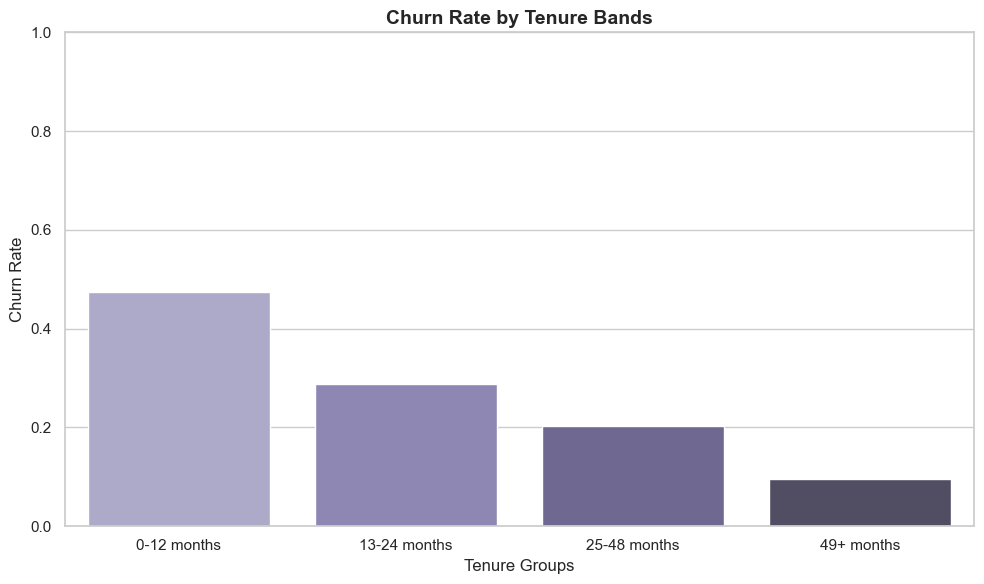

Saved: reports/figures/churn_by_tenure_bands.png


In [20]:
bins = [0, 12, 24, 48, 72]
labels = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
df['tenure_group'] = pd.cut(
    df['tenure'], bins=bins, labels=labels, include_lowest=True
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='tenure_group',
    y='Churn_flag',
    errorbar=None,
    palette='Purples_d',
    hue='tenure_group',
    legend=False,
)
plt.title('Churn Rate by Tenure Bands', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Groups', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('reports/figures/churn_by_tenure_bands.png', dpi=300)
plt.show()
print('Saved: reports/figures/churn_by_tenure_bands.png')

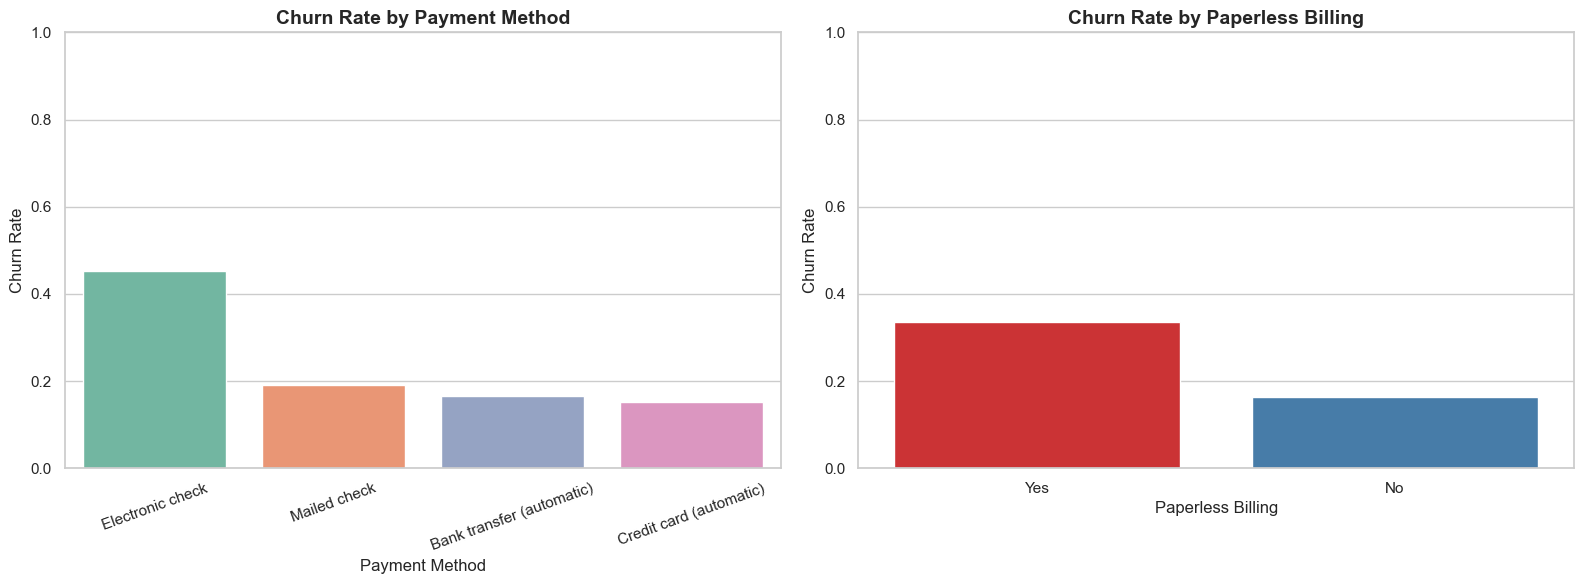

Saved: reports/figures/churn_by_payment_paperless.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Churn Rate by Payment Method
sns.barplot(
    data=df,
    x='PaymentMethod',
    y='Churn_flag',
    errorbar=None,
    palette='Set2',
    ax=axes[0],
    hue='PaymentMethod',
    legend=False,
)
axes[0].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Payment Method', fontsize=12)
axes[0].set_ylabel('Churn Rate', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)  # Fixed using tick_params instead of set_xticklabels directly
axes[0].set_ylim(0, 1)

# 2. Churn Rate by Paperless Billing
sns.barplot(
    data=df,
    x='PaperlessBilling',
    y='Churn_flag',
    errorbar=None,
    palette='Set1',
    ax=axes[1],
    hue='PaperlessBilling',
    legend=False,
)
axes[1].set_title(
    'Churn Rate by Paperless Billing', fontsize=14, fontweight='bold'
)
axes[1].set_xlabel('Paperless Billing', fontsize=12)
axes[1].set_ylabel('Churn Rate', fontsize=12)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('reports/figures/churn_by_payment_paperless.png', dpi=300)
plt.show()
print('Saved: reports/figures/churn_by_payment_paperless.png')

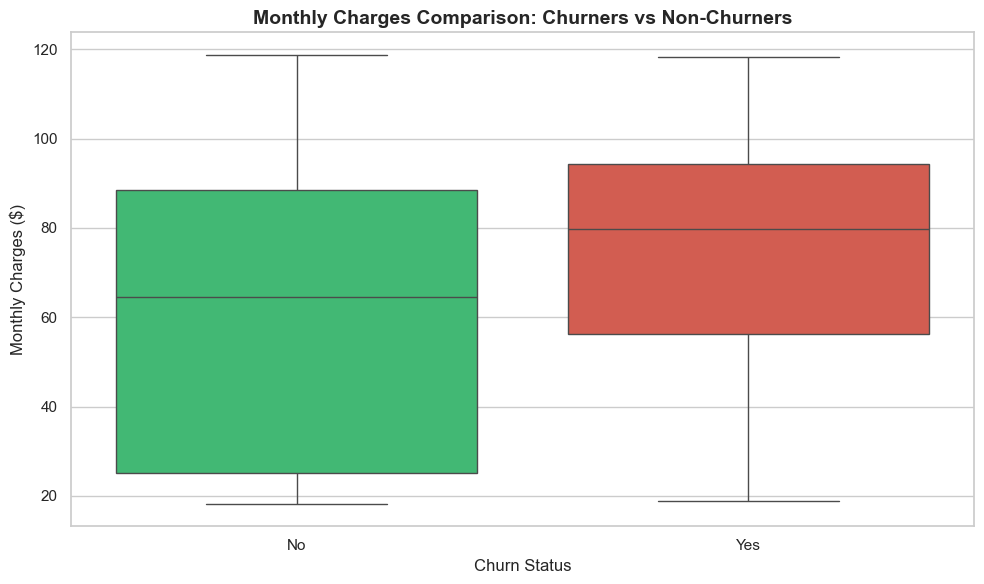

Saved: reports/figures/monthly_charges_boxplot.png


In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges',
    palette=['#2ecc71', '#e74c3c'],
    hue='Churn',
    legend=False,
)
plt.title(
    'Monthly Charges Comparison: Churners vs Non-Churners',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)

plt.tight_layout()
plt.savefig('reports/figures/monthly_charges_boxplot.png', dpi=300)
plt.show()
print(
    'Saved: reports/figures/monthly_charges_boxplot.png'
)

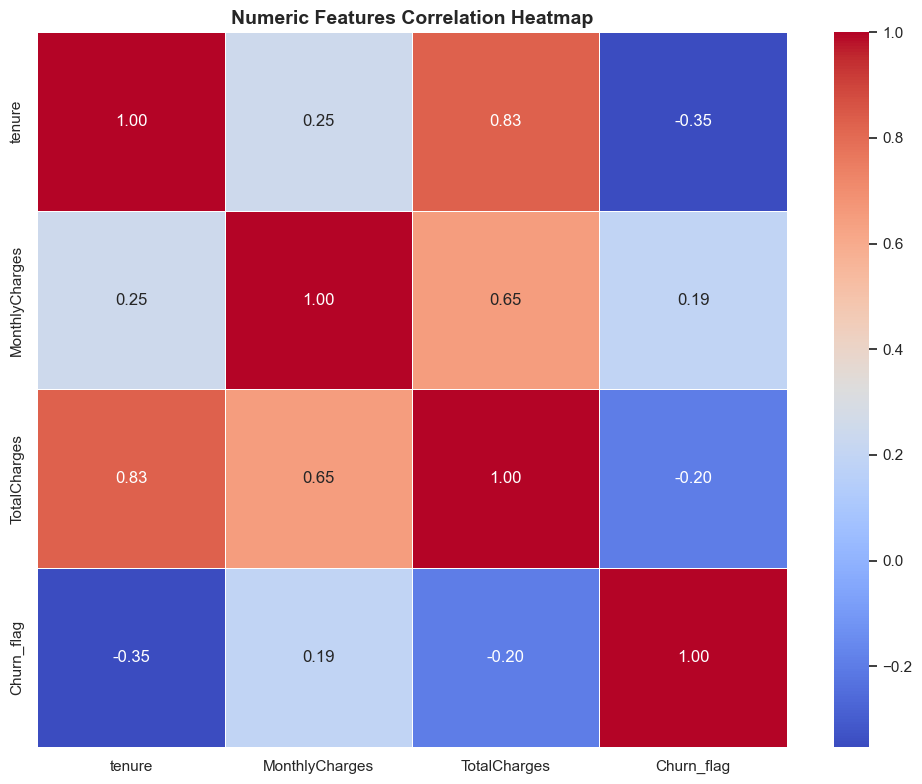

Saved: reports/figures/correlation_heatmap.png


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns including Churn_flag
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5
)
plt.title(
    'Numeric Features Correlation Heatmap', fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig('reports/figures/correlation_heatmap.png', dpi=300)
plt.show()
print('Saved: reports/figures/correlation_heatmap.png')

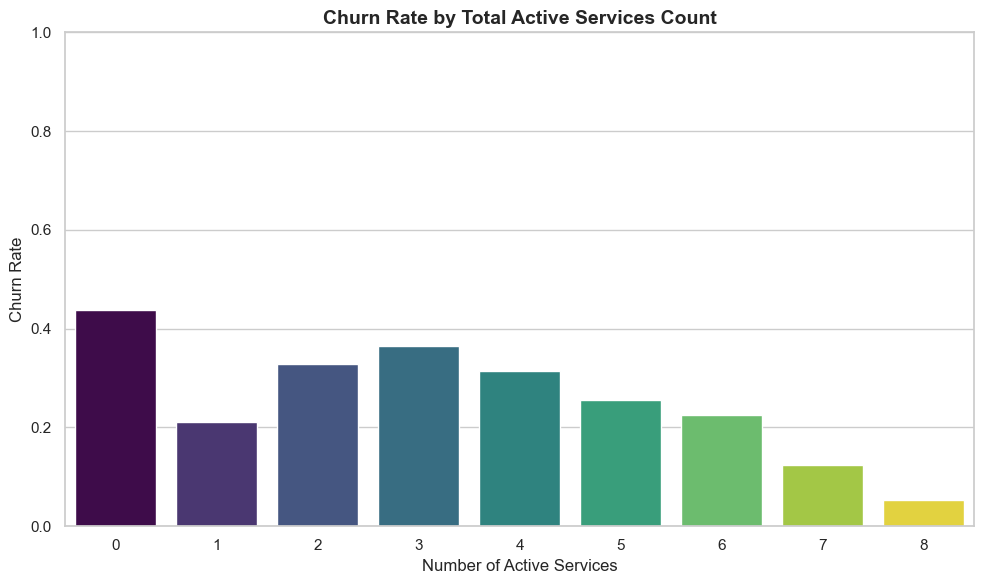

Saved: reports/figures/churn_by_service_count.png


In [27]:
# Count how many add-on/phone/internet services each customer has active
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PhoneService',
    'MultipleLines',
]
df['service_count'] = (df[service_cols] == 'Yes').sum(axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='service_count',
    y='Churn_flag',
    errorbar=None,
    palette='viridis',
    hue='service_count',
    legend=False,
)
plt.title(
    'Churn Rate by Total Active Services Count', fontsize=14, fontweight='bold'
)
plt.xlabel('Number of Active Services', fontsize=12)
plt.ylabel('Churn Rate', fontsize=12)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('reports/figures/churn_by_service_count.png', dpi=300)
plt.show()
print('Saved: reports/figures/churn_by_service_count.png')

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='Contract',
    y='tenure',
    hue='Churn',
    palette=['#2ecc71', '#e74c3c'],
)
plt.title(
    'Tenure Distribution by Contract Type and Churn Status',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)
plt.legend(title='Churn')

plt.tight_layout()
plt.savefig('reports/figures/contract_tenure_churn.png', dpi=300)
plt.show()
print('Saved: reports/figures/contract_tenure_churn.png')

## Executive Summary: Key Churn Insights

1. **Overall Churn Rate & Class Imbalance:**
   - The dataset reveals an overall churn rate of approximately **26.5%** (1,869 churned customers out of 7,043), while 73.5% remain active. This represents a moderate class imbalance that must be handled during machine learning modeling.

2. **Contract Type as the Primary Churn Driver:**
   - **Month-to-month** contracts exhibit the highest churn rate at **~42%**. In contrast, customers on Two-year contracts demonstrate extreme loyalty, with churn rates dropping below **3%**.

3. **Critical Onboarding Window (Tenure):**
   - New customers within the **0–12 months tenure** band face the highest risk of attrition (**~47% churn rate**). As customer tenure increases toward 49+ months, the churn rate decreases sharply to under 10%.

4. **Fiber Optic Pricing & Service Vulnerability:**
   - Customers utilizing **Fiber optic** internet services experience a significantly higher churn rate compared to DSL users or those without internet service, highlighting potential pricing or service-quality sensitivities.

5. **Payment Method & Billing Risk Factors:**
   - Payments made via **Electronic check** correlate with the highest churn rate (**~45%**), whereas automated payment methods (Bank transfer and Credit card) show much lower attrition.

6. **Impact of Monthly Charges:**
   - Churning customers tend to have higher monthly expenditures, with a median of roughly **$80**, indicating that higher-tier pricing plans are more prone to customer loss.

7. **The Retention Power of Service Bundling:**
   - Customers who subscribe to multiple add-on services (such as Online Security, Device Protection, and TechSupport) show significantly lower churn rates, proving that service bundling effectively locks in customers.

In [33]:
#Phase 2.1: Feature Engineering
#Cell 1: Creating New Features

import numpy as np
import pandas as pd

# 1. Tenure Groups (Bands)
bins = [0, 12, 24, 48, 72]
labels = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
df['tenure_group'] = pd.cut(
    df['tenure'], bins=bins, labels=labels, include_lowest=True
)

# 2. Total Active Services Count (kitni services customer use kar raha hai)
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PhoneService',
    'MultipleLines',
]
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# 3. Average Monthly Spend (TotalCharges / tenure, handling division by zero where tenure is 0)
df['avg_monthly_spend'] = np.where(
    df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
)

# 4. Bundle Flags (Has Streaming, Has Security Bundle)
df['has_streaming'] = (
    (df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')
).astype(int)
df['has_security_bundle'] = (
    (df['OnlineSecurity'] == 'Yes') & (df['TechSupport'] == 'Yes')
).astype(int)

# 5. Is Autopay Flag (Payment method ke zariye automatic payment check karna)
df['is_autopay'] = df['PaymentMethod'].str.contains('automatic').astype(int)

print('Feature engineering completed successfully!')
print('New shape of DataFrame:', df.shape)

Feature engineering completed successfully!
New shape of DataFrame: (7043, 29)


In [35]:
"""Phase 2.2: Encoding and Scaling Preparation
Cell 2: Separating Features (X) and Target (y), and Dropping Unnecessary Identifiers"""


# Drop customerID and original Churn column (we will use Churn_flag as target)
# Also drop tenure_group as it's a categorical version of tenure (we can keep tenure numeric)
X = df.drop(
    columns=[
        'customerID',
        'Churn',
        'Churn_flag',
        'tenure_group',
        'total_charges_numeric',
    ],
    errors='ignore',
)
y = df['Churn_flag']

print('Features shape (X):', X.shape)
print('Target shape (y):', y.shape)
print('\nColumns in X:', X.columns.tolist())

Features shape (X): (7043, 25)
Target shape (y): (7043,)

Columns in X: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'service_count', 'num_services', 'avg_monthly_spend', 'has_streaming', 'has_security_bundle', 'is_autopay']


In [36]:
"""Phase 2.3: Split Strategy & Preprocessing Pipeline (Avoiding Data Leakage)
Cell 3: Stratified Train/Test Split & ColumnTransformer Pipeline
Yeh cell data ko 80/20 ratio mein split karega aur ensure karega ke preprocessing sirf train fold par fit ho (data leakage se bachne ke liye):"""


from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Stratified Train/Test Split (80% train, 20% test, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train set shape:', X_train.shape)
print('Test set shape:', X_test.shape)

# 2. Identify Numeric and Categorical columns for Pipeline
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print('\nNumeric features:', numeric_features)
print('Categorical features:', categorical_features)

# 3. Create Preprocessing Pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features,
        ),  # StandardScaler for numeric columns
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', drop='first'),
            categorical_features,
        ),  # OneHotEncoder for categorical
    ]
)

print(
    '\nPreprocessing pipeline (ColumnTransformer) successfully initialized!'
)

Train set shape: (5634, 25)
Test set shape: (1409, 25)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'service_count', 'num_services', 'avg_monthly_spend', 'has_streaming', 'has_security_bundle', 'is_autopay']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Preprocessing pipeline (ColumnTransformer) successfully initialized!
